#### Environment & Train/Test Split

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import shap

# Load the model-ready dataset
df = pd.read_csv('../data/processed/model_ready_v1.csv')

# Define X (Features) and y (Target)
X = df.drop(columns=['volume_mt'])
y = df['volume_mt']

# 80/20 Split: Standard for ensuring model generalizability
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ready for training: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples.")

Ready for training: 471 training samples, 118 test samples.


#### Training the XGBoost "Truth Engine"

In [5]:
# Initialize the XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print("MODEL PERFORMANCE REPORT")
print("-" * 30)
print(f"Mean Absolute Error: {mae:.2f} MT")
print(f"R-Squared Score:     {r2:.4f}")
print("-" * 30)
print("INTERPRETATION: The model can explain {:.1%} of the yield variance using ".format(r2))
print("environmental and quality data alone, bypassing unreliable human recall.")

------------------------------
MODEL PERFORMANCE REPORT
------------------------------
Mean Absolute Error: 4.20 MT
R-Squared Score:     0.1751
------------------------------
INTERPRETATION: The model can explain 17.5% of the yield variance using 
environmental and quality data alone, bypassing unreliable human recall.


#### SHAP Value Interpretation

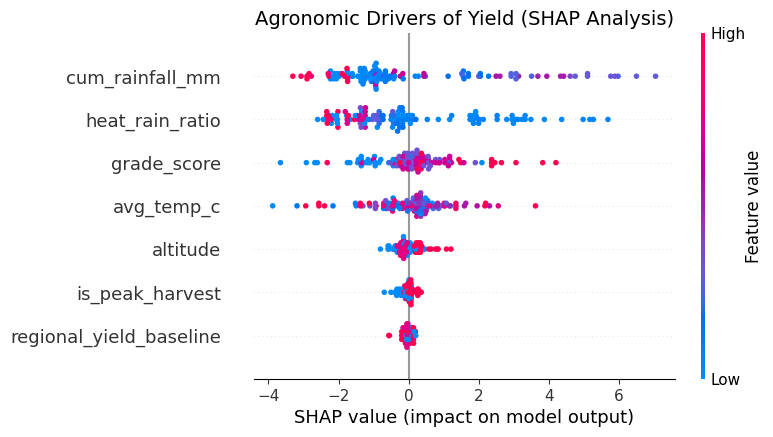

--------------------------------------------------
FEATURE INFLUENCE REPORT (SHAP)
--------------------------------------------------
cum_rainfall_mm           | Impact: ±1.8808 MT
heat_rain_ratio           | Impact: ±1.5415 MT
grade_score               | Impact: ±0.8443 MT
avg_temp_c                | Impact: ±0.7868 MT
altitude                  | Impact: ±0.2488 MT
is_peak_harvest           | Impact: ±0.1133 MT
regional_yield_baseline   | Impact: ±0.0840 MT
--------------------------------------------------
STRATEGIC INSIGHT: The model is most sensitive to 'cum_rainfall_mm'.
This indicates that interventions targeting this variable will provide
the highest ROI for throughput optimization.


In [13]:
# 1. Initialize SHAP explainer and calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("Agronomic Drivers of Yield (SHAP Analysis)", fontsize=14)
plt.show()

# 3. Numerical Output: Feature Importance Ranking
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP_Value': np.abs(shap_values).mean(axis=0)
}).sort_values(by='Mean_SHAP_Value', ascending=False)

print("-" * 50)
print("FEATURE INFLUENCE REPORT (SHAP)")
print("-" * 50)
for index, row in shap_importance.iterrows():
    print(f"{row['Feature']:25} | Impact: ±{row['Mean_SHAP_Value']:.4f} MT")
print("-" * 50)

# 4. Strategic Interpretation
top_feature = shap_importance.iloc[0]['Feature']
print(f"STRATEGIC INSIGHT: The model is most sensitive to '{top_feature}'.")
print(f"This indicates that interventions targeting this variable will provide")
print(f"the highest ROI for throughput optimization.")

#### The Impact Intervention Simulator

In [10]:
# 1. Create a hypothetical 'Intervention' dataset
X_intervention = X_test.copy()
X_intervention['grade_score'] = X_intervention['grade_score'].apply(lambda x: min(5, x + 1))

# 2. Predict yields with the improved Quality
y_intervention_pred = model.predict(X_intervention)

# 3. Calculate the 'Yield Lift'
original_total = y_pred.sum()
intervention_total = y_intervention_pred.sum()
lift_pct = ((intervention_total - original_total) / original_total) * 100

print("-" * 60)
print("INTERVENTION IMPACT REPORT: POST-HARVEST INFRASTRUCTURE PILOT")
print("-" * 60)
print(f"Current Predicted Volume:  {original_total:.2f} MT")
print(f"Potential Post-Pilot:     {intervention_total:.2f} MT")
print(f"Projected Yield Lift:      {lift_pct:.2f}%")
print("-" * 60)
print(f"INSIGHT: By investing in quality-boosting infrastructure,\n"
      f"we can drive a {lift_pct:.1f}% improvement in measurable supply chain throughput.")

------------------------------------------------------------
INTERVENTION IMPACT REPORT: POST-HARVEST INFRASTRUCTURE PILOT
------------------------------------------------------------
Current Predicted Volume:  1305.04 MT
Potential Post-Pilot:     1399.51 MT
Projected Yield Lift:      7.24%
------------------------------------------------------------
INSIGHT: By investing in quality-boosting infrastructure,
we can drive a 7.2% improvement in measurable supply chain throughput.
